<a href="https://colab.research.google.com/github/konishogu/DeepLearning-SIMPSON/blob/main/DLY01100_EV2_003D_GRUPO_DEEPER_LEANER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



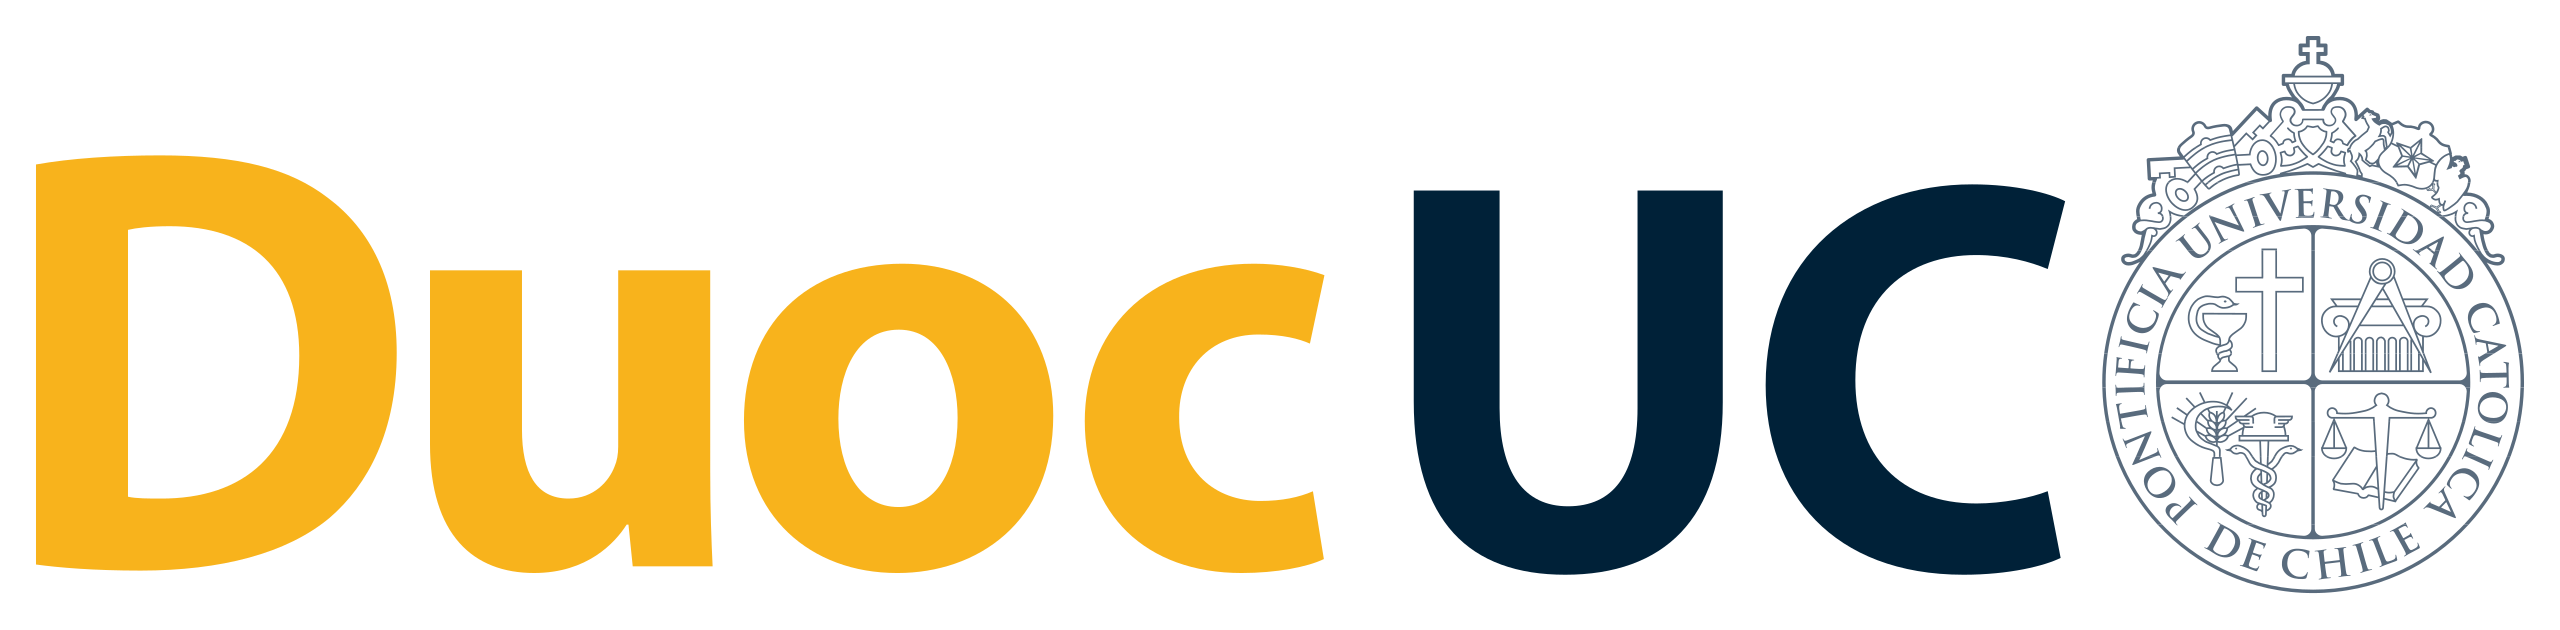



---
**Autores:**

- Matias Ignacio Wastavino Gonzalez
- Luis Rodrigo Nicolas Mendez Lehner
- Rodrigo Antonio Carcamo Rojas
- Matias Ignacio Molina Sepulveda
- Alejandra Ignacia Riquelme Velásquez

**Docente:** Marcelo Alejandro Tapia Contreras

**Asignatura:** Deep learning

**Sección:** 003D

**Institución:** Duoc UC - Sede Melipilla

**Fecha de entrega:** 22 de Mayo de 2026

---

## **1. INTRODUCCIÓN**

Las redes neuronales convolucionales (CNN) representan una de las arquitecturas más utilizadas en tareas de visión computacional y clasificación de imágenes, debido a su capacidad para extraer automáticamente características visuales relevantes. En este trabajo se aborda un problema de clasificación de imágenes utilizando un dataset compuesto por personajes de la serie Los Simpsons. Este conjunto de datos presenta una complejidad mayor en comparación con datasets tradicionales como MNIST o Fashion MNIST, ya que los personajes aparecen en distintas posiciones, poses, escalas e incluso acompañados por otros personajes dentro de la misma imagen. El objetivo principal del trabajo consiste en implementar y optimizar una CNN utilizando TensorFlow/Keras, evaluando distintas arquitecturas e hiperparámetros para alcanzar un rendimiento superior al 85% de accuracy sobre el conjunto de prueba.

<center><img src="https://i.imgur.com/i8zIGqX.jpg" style="text-align: center" height="300px"></center>

## **2. IMPORTACIÓN DE LIBRERÍAS**

En esta sección se importan las librerías necesarias para el desarrollo del proyecto de clasificación de imágenes mediante redes neuronales convolucionales (CNN).

In [ ]:
# Librerías para visualización y procesamiento de imágenes
from google.colab.patches import cv2_imshow
import cv2
import os
import glob
import itertools
import collections
import subprocess

# Librerías para manejo numérico y visualización de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# TensorFlow y Keras para construcción de la CNN
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Dense,
    Activation,
    Dropout,
    Flatten,
    BatchNormalization,
    MaxPooling2D,
    Conv2D
)

# Herramientas para preprocesamiento y optimización
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, SGD

# Librerías para evaluación del modelo
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay
from sklearn import metrics
import seaborn as sns
from sklearn.model_selection import train_test_split

## **3. CARGA DEL DATASET**

### **3.1. Creación de directorio**

Antes de descargar el dataset, es necesario crear un directorio de trabajo donde se almacenarán los archivos utilizados durante el desarrollo del proyecto. En Google Colab, el entorno de ejecución es temporal, por lo que cada vez que la máquina virtual se reinicia se eliminan los archivos almacenados anteriormente. Por esta razón, se crea automáticamente la carpeta '/root/.keras/datasets', utilizada por Keras como ubicación estándar para guardar datasets descargados. Esto permite mantener una estructura organizada y asegurar que las imágenes puedan ser encontradas correctamente durante la carga y el entrenamiento del modelo.

In [ ]:
# Crea la carpeta donde se almacenarán los datasets descargados
os.makedirs('/root/.keras/datasets', exist_ok=True)

### **3.2. Descarga de datos**

En esta etapa se descargan los archivos comprimidos que contienen el dataset de entrenamiento y prueba utilizado en el proyecto. Para ello se utiliza la herramienta 'gdown', que permite descargar archivos directamente desde Google Drive mediante un identificador único. Los archivos descargados se almacenan en el directorio creado previamente, permitiendo disponer localmente de las imágenes necesarias para el entrenamiento y evaluación de la red neuronal convolucional.

In [ ]:
# Descarga el dataset de entrenamiento desde Google Drive y lo guarda en el directorio
print("⬇Descargando simpsons_train.tar.gz ...")
!gdown 1snRV751UeWXFVJVgBvhY2pfiqAx_95yS -O /root/.keras/datasets/simpsons_train.tar.gz

# Descarga el dataset de prueba desde Google Drive y lo guarda en el directorio
print("⬇Descargando simpsons_test.tar.gz ...")
!gdown 1Cu0Z-26STopwxlnZ032Xh1ScDoHk7Zfj -O /root/.keras/datasets/simpsons_test.tar.gz

⬇Descargando simpsons_train.tar.gz ...
Downloading...
From: https://drive.google.com/uc?id=1snRV751UeWXFVJVgBvhY2pfiqAx_95yS
To: /root/.keras/datasets/simpsons_train.tar.gz
100% 10.7M/10.7M [00:00<00:00, 28.3MB/s]
⬇Descargando simpsons_test.tar.gz ...
Downloading...
From (original): https://drive.google.com/uc?id=1Cu0Z-26STopwxlnZ032Xh1ScDoHk7Zfj
From (redirected): https://drive.google.com/uc?id=1Cu0Z-26STopwxlnZ032Xh1ScDoHk7Zfj&confirm=t&uuid=96c367b8-cd2b-4f4f-88ae-20ba16dce8b8
To: /root/.keras/datasets/simpsons_test.tar.gz
100% 524M/524M [00:07<00:00, 67.6MB/s]


### **3.3. Descomprensión**

Una vez descargados los archivos comprimidos del dataset, es necesario extraer su contenido para poder acceder a las imágenes utilizadas en el entrenamiento y prueba del modelo. Para ello se utiliza el comando 'tar', el cual descomprime los archivos '.tar.gz' y almacena las carpetas resultantes dentro del directorio de trabajo configurado previamente.

In [ ]:
# Descomprime el dataset de entrenamiento dentro del directorio
!tar -xzf /root/.keras/datasets/simpsons_train.tar.gz -C /root/.keras/datasets --ignore-zeros

# Descomprime el dataset de prueba dentro del directorio
!tar -xzf /root/.keras/datasets/simpsons_test.tar.gz -C /root/.keras/datasets --ignore-zeros

### **3.4. Verificación de archivos**

Después de descargar y descomprimir los datasets, se realiza una verificación del contenido almacenado en el directorio de trabajo. Esto permite comprobar que los archivos y carpetas fueron creados correctamente antes de continuar con la carga y procesamiento de imágenes.

In [ ]:
# Muestra los archivos y carpetas disponibles dentro del directorio
print("\nContenido descargado:")
!ls /root/.keras/datasets/


Contenido descargado:
simpsons  simpsons_testset  simpsons_test.tar.gz  simpsons_train.tar.gz


### **3.5. Configuración del dataset**

In [ ]:
# Mapeo entre etiquetas numéricas y personajes del dataset
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy',
    6: 'edna_krabappel', 7: 'homer_simpson', 8: 'kent_brockman',
    9: 'krusty_the_clown', 10: 'lisa_simpson', 11: 'marge_simpson',
    12: 'milhouse_van_houten', 13: 'moe_szyslak', 14: 'ned_flanders',
    15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}

# Tamaño estándar utilizado para redimensionar todas las imágenes
IMG_SIZE = 64

## **4. CARGA DE IMÁGENES**

### **4.1. Función de carga de entrenamiento**

In [ ]:
def load_train_set(dirname, map_characters, verbose=True):

    # Lista donde se almacenarán las imágenes
    X_train = []
    # Lista donde se almacenarán las etiquetas
    y_train = []

    # Recorre cada personaje y su etiqueta numérica
    for label, character in map_characters.items():

        # Obtiene los archivos de la carpeta del personaje
        files = os.listdir(os.path.join(dirname, character))

        # Filtra únicamente imágenes .jpg
        images = [file for file in files if file.endswith("jpg")]
        if verbose:
          print("Leyendo {} imágenes encontradas de {}".format(len(images), character))

        # Recorre cada imagen encontrada
        for image_name in images:

            # Lee la imagen desde el directorio
            image = cv2.imread(os.path.join(dirname, character, image_name))

            # Redimensiona la imagen y la guarda
            X_train.append(cv2.resize(image,(IMG_SIZE, IMG_SIZE)))

            # Guarda la etiqueta correspondiente al personaje
            y_train.append(label)

    # Convierte las listas a arrays NumPy y las retorna
    return np.array(X_train), np.array(y_train)

### **4.2. Función de carga de test**

In [ ]:
def load_test_set(dirname, map_characters, verbose=True):

    # Lista donde se almacenarán las imágenes
    X_test = []
    # Lista donde se almacenarán las etiquetas
    y_test = []

    # Invierte el diccionario
    reverse_dict = {v: k for k, v in map_characters.items()}

    # Recorre todos los archivos del directorio
    for filename in glob.glob(dirname + '/*.*'):

        # Extrae el nombre del personaje desde el archivo
        char_name = "_".join(filename.split('/')[-1].split('_')[:-1])

        # Verifica que el personaje exista en el diccionario
        if char_name in reverse_dict:

            # Lee la imagen usando OpenCV
            image = cv2.imread(filename)

            # Redimensiona la imagen al tamaño definido
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

            # Guarda la imagen procesada
            X_test.append(image)

            # Guarda la etiqueta correspondiente al personaje
            y_test.append(reverse_dict[char_name])

    if verbose:
        print("Leídas {} imágenes de test".format(len(X_test)))

    # Convierte las listas a arrays NumPy y las retorna
    return np.array(X_test), np.array(y_test)

### **4.3. Carga del dataset en memoria**

In [ ]:
# Ruta donde se encuentran las imágenes de entrenamiento
DATASET_TRAIN_PATH_COLAB = "/root/.keras/datasets/simpsons"

# Ruta donde se encuentran las imágenes de test
DATASET_TEST_PATH_COLAB = "/root/.keras/datasets/simpsons_testset"

# Carga las imágenes y etiquetas del conjunto de entrenamiento
X, y = load_train_set(DATASET_TRAIN_PATH_COLAB, MAP_CHARACTERS)

# Carga las imágenes y etiquetas del conjunto de prueba
X_t, y_t = load_test_set(DATASET_TEST_PATH_COLAB, MAP_CHARACTERS)

Leyendo 913 imágenes encontradas de abraham_grampa_simpson
Leyendo 623 imágenes encontradas de apu_nahasapeemapetilon
Leyendo 1342 imágenes encontradas de bart_simpson
Leyendo 1193 imágenes encontradas de charles_montgomery_burns
Leyendo 986 imágenes encontradas de chief_wiggum
Leyendo 469 imágenes encontradas de comic_book_guy
Leyendo 457 imágenes encontradas de edna_krabappel
Leyendo 2246 imágenes encontradas de homer_simpson
Leyendo 498 imágenes encontradas de kent_brockman
Leyendo 1206 imágenes encontradas de krusty_the_clown
Leyendo 1354 imágenes encontradas de lisa_simpson
Leyendo 1291 imágenes encontradas de marge_simpson
Leyendo 1079 imágenes encontradas de milhouse_van_houten
Leyendo 1452 imágenes encontradas de moe_szyslak
Leyendo 1454 imágenes encontradas de ned_flanders
Leyendo 358 imágenes encontradas de nelson_muntz
Leyendo 1194 imágenes encontradas de principal_skinner
Leyendo 877 imágenes encontradas de sideshow_bob
Leídas 890 imágenes de test


### **4.4. Mezcla aleatoria del dataset**

In [ ]:
# Genera un orden aleatorio para mezclar las imágenes
perm = np.random.permutation(len(X))

# Reorganiza imágenes y etiquetas manteniendo su correspondencia
X, y = X[perm], y[perm]

## **5. EXPLORACIÓN Y ANÁLISIS DE DATOS**

### **5.1. Ver dimensiones del dataset**

En esta etapa se verifican las dimensiones de los conjuntos de entrenamiento y prueba cargados en memoria. El propósito de este apartado es comprobar que las imágenes y sus etiquetas fueron almacenadas correctamente, asegurando que la cantidad de datos y la estructura de las matrices sean adecuadas para el entrenamiento de la red. Además, esta validación permite detectar posibles inconsistencias antes de continuar con las siguientes secciones.

In [ ]:
print(f"------------------------------------------------")
print(f"Imágenes de entrenamiento: {X.shape}")
print(f"------------------------------------------------")
print(f"Etiquetas de entrenamiento: {y.shape}")
print(f"------------------------------------------------")
print(f"Imágenes de prueba: {X_t.shape}")
print(f"------------------------------------------------")
print(f"Etiquetas de prueba: {y_t.shape}")
print(f"------------------------------------------------")

------------------------------------------------
Imágenes de entrenamiento: (18992, 64, 64, 3)
------------------------------------------------
Etiquetas de entrenamiento: (18992,)
------------------------------------------------
Imágenes de prueba: (890, 64, 64, 3)
------------------------------------------------
Etiquetas de prueba: (890,)
------------------------------------------------


**CONCLUSIÓN:** La salida obtenida confirma que el dataset fue cargado correctamente en memoria. El conjunto de entrenamiento contiene 18.992 imágenes con dimensiones de 64x64 píxeles y 3 canales de color RGB, mientras que el conjunto de prueba contiene 890 imágenes con las mismas características. Las etiquetas de entrenamiento y prueba presentan una dimensión de una sola columna, lo que indica que cada imagen posee una clase asociada correspondiente a uno de los personajes del dataset. Además, se verifica que todas las imágenes fueron estandarizadas al mismo tamaño, lo cual es fundamental para el correcto funcionamiento de una CNN, ya que el modelo requiere entradas con dimensiones uniformes durante el proceso de entrenamiento y evaluación.

### **5.2. Mostrar imágenes ejemplo [NO EJECUTAR LA CELDA DE CÓDIGO]**

En esta etapa se realiza una visualización de algunas imágenes pertenecientes al conjunto de entrenamiento. Este proceso permite verificar que las imágenes fueron cargadas correctamente, que las etiquetas coinciden con cada personaje y que el formato de color y dimensiones son adecuados para el procesamiento de la CNN. Además, esta exploración permite observar la variabilidad visual presente en el dataset, identificando diferencias de poses, expresiones, iluminación, tamaños y fondos entre las imágenes. También ayuda a detectar posibles problemas como imágenes corruptas, ruido o similitudes visuales entre personajes, factores que aumentan la complejidad del problema de clasificación.

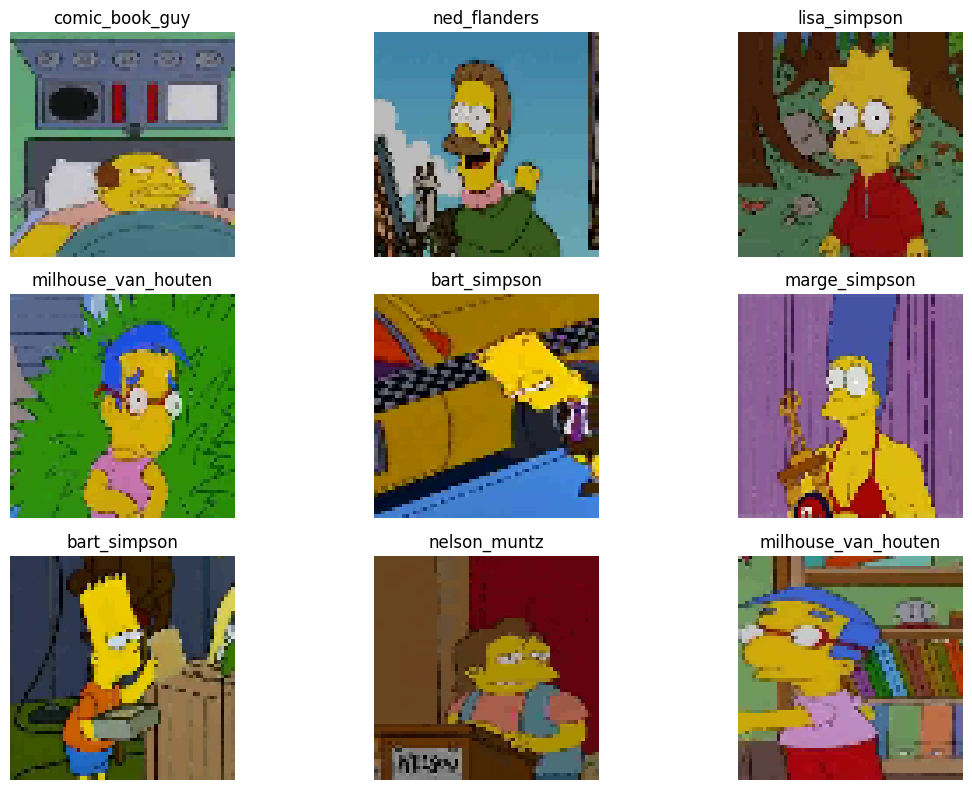

In [ ]:
# Crea una figura para visualizar imágenes
plt.figure(figsize=(12,8))

# Recorre las primeras 9 imágenes del dataset
for i in range(9):

    # Organiza las imágenes en una cuadrículas 3x3
    plt.subplot(3,3,i+1)

    # Convierte la imagen de BGR a RGB y la muestra
    plt.imshow(cv2.cvtColor(X[i], cv2.COLOR_BGR2RGB))

    # Obtiene la etiqueta correspondiente
    label = y[i]

    # Muestra el nombre del personaje
    plt.title(MAP_CHARACTERS[label])

    # Oculta los ejes de la imagen
    plt.axis("off")

# Ajusta automáticamente los espacios
plt.tight_layout()

# Muestra la visualización final
plt.show()

**CONCLUSIONES:**

1. Se observan diferencias de poses, ángulos, iluminación, expresiones faciales y fondos. Por ejemplo, Lisa aparece de perfil, mientras que Homer se muestra en dos escenarios distintos y Milhouse cambia de posición y tamaño entre imágenes. Esto implica que la red no puede limitarse a memorizar imágenes específicas, sino que debe aprender patrones generales que permitan reconocer a cada personaje en diferentes contextos.

2. También se identificaron diferencias de escala y encuadre. Algunos personajes ocupan casi toda la imagen, mientras que otros aparecen más alejados o parcialmente visibles. Por ejemplo, Lisa aparece en un primer plano donde su rostro ocupa gran parte del recuadro, mientras que Milhouse y Sideshow Bob aparecen en planos más amplios mostrando parte del cuerpo y la vestimenta. Esta variabilidad aumenta la complejidad del problema, ya que la red debe reconocer personajes aunque cambien de tamaño, posición o no se encuentren centrados en la imagen.

3. Otro aspecto relevante es la similitud visual entre algunos personajes. Muchos comparten colores, estilos de dibujo y rasgos faciales similares. Esto obliga a la red a aprender atributos más específicos, como formas de ojos, peinados, accesorios, contornos y proporciones faciales, evitando depender únicamente del color para clasificar correctamente.

4. Además, el dataset contiene ruido visual. Varias imágenes presentan fondos complejos, objetos adicionales e incluso otros personajes dentro de la escena. Por ejemplo, Ned Flanders en la taberna de Moe o Homer conduciendo, el fondo incorpora múltiples elementos que no aportan directamente a la clasificación. A diferencia de datasets más simples como MNIST, donde el fondo es uniforme, aquí la red debe aprender a distinguir el personaje principal del resto de la escena.

5. Por otra parte, todas las imágenes fueron redimensionadas a 64x64 píxeles. Sin embargo, esta reducción también disminuye el nivel de detalle visual, dificultando la diferenciación entre personajes similares. Debido a esto, la red deberá extraer características relevantes incluso en imágenes de baja resolución.

### **5.3. Distribución de clases**

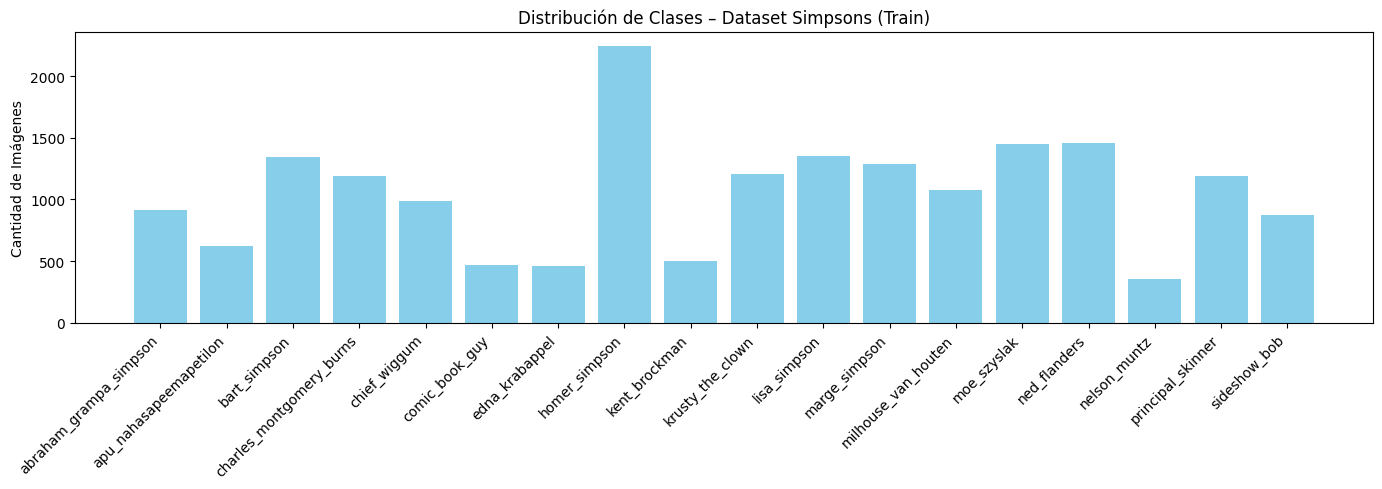

In [ ]:
# Cuenta cuántas imágenes existen por cada clase
unique, counts = np.unique(y, return_counts=True)

# Obtiene el nombre de cada personaje
labels = [MAP_CHARACTERS[i] for i in unique]

# Crea la figura del gráfico
plt.figure(figsize=(14, 5))

# Genera el gráfico de barras
plt.bar(labels, counts, color='skyblue')
# Título del gráfico
plt.title("Distribución de Clases – Dataset Simpsons (Train)")
# Nombre del eje
plt.ylabel("Cantidad de Imágenes")
# Rota las etiquetas
plt.xticks(rotation=45, ha='right')
# Ajusta los espacios
plt.tight_layout()
# Muestra el gráfico
plt.show()

**CONCLUSIONES:** En este gráfico, se puede visualizar la cantidad de imágenes que contiene cada variable o clase (personaje) en el set de datos de entrenamiento. Podemos observar que la clase con más imágenes es la de "Homer_Simpson" con una cantidad de 2.200. Por otro lado, debemos tener en cuenta que hay varias clases que tienen una cantidad de imágenes que están entre las 1.000 y las 1.500, como las de “Bart, Lisa, Marge, Moe, Ned Flanders y Mr.Burns”, y hay otro conjunto de clases que no tienen más de 500 imágenes, como por ejemplo “Edna Krabapple” o “Kent Brockman”.

Esto podría afectar bastante al modelo, ya que si los datos se dejan así como están (desbalanceados), el modelo podría ver a Homero casi siete veces más que a Nelson. Gracias al sesgo por ser la clase mayoritaria, la red aprenderá extremadamente bien las características visuales de Homero, pero podría predecir “Homero” cuando tenga dudas con otros personajes (Falsos positivos), si este modelo pasa a evaluarse usando el Accuracy global, podría dar valores altos solamente porque acierta casi siempre con la clase mayoritaria “Homero”, y el resto de personajes que tienen una cantidad de imágenes que rondan las 1.000 y las 1.500 ocultando el pésimo rendimiento que tendrá al clasificar a los personajes de las clases minoritarias, como por ejemplo “Nelson” o “Comic Book Guy”. Por otro lado, las clases que tienen menos de 500 imágenes corren riesgo de sufrir sobreajuste, ya que el modelo tiene pocas variantes visuales(Fondos, Ángulos, expresiones) para aprender a generalizar correctamente a esos personajes.


## **6. PREPROCESAMIENTO**

# 6.1 balance de clases

El analisis inicial del dataset evidencia un desbalance significativo en la distribución de clases, la clase “homer_simpson” presenta la mayor cantidad de muestras 2246 imágenes, mientras que otras clases, como “nelson_muntz” 358 imágenes o “edna_krabappel” 457 imágenes, tienen una representación considerable menor. Este desbalance puede inducir un sesgo en el modelo de clasificación, favoreciendo la predicción de las clases mayoritarias y afectando negativamente el desempeño en clases minoritarios.

In [ ]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Distribución actual
unique, counts = np.unique(y, return_counts=True)
target_count = counts.max()   # objetivo = clase con mas muestras

print(f"Clase mayoritaria: {MAP_CHARACTERS[unique[counts.argmax()]]} "
      f"con {target_count} imágenes")
print(f"Objetivo por clase: {target_count} imágenes\n")

# Generador de augmentation
augmenter = ImageDataGenerator(
    rotation_range=12,           # rotación leve°
    width_shift_range=0.08,      # desplazamiento horizontal
    height_shift_range=0.08,     # desplazamiento vertical
    zoom_range=0.10,             # zoom
    horizontal_flip=True,         # invierte la imagen horizontalmente sin cambiar la clase del personaje
    brightness_range=(0.85, 1.15),  # variación de brillo
    fill_mode="nearest",
)

X_extra = []
y_extra = []

for label in unique:
    idx_class = np.where(y == label)[0] # busca en las etiquetas del entrenamiento las posiciones que pertenecen a esta clase
    n_actual = len(idx_class)  # cuenta cuántas imágenes tiene esta clase
    n_faltantes = target_count - n_actual # contamos cuantas meustras nos faltan, teniendo encuenta la clase con mas muestras como objetivo

    if n_faltantes <= 0:#si ya cumple no hace nada
        print(f"  {MAP_CHARACTERS[label]:30s} → ya tiene {n_actual} (OK)")
        continue

    print(f"  {MAP_CHARACTERS[label]:30s} → generando {n_faltantes} muestras "
          f"(tiene {n_actual})")

    X_clase = X[idx_class]  # imágenes originales

    # Genera lotes de imágenes modificadas a partir de lo especificado en el argumenter
    flow = augmenter.flow(
        X_clase,
        batch_size=min(32, n_actual),# define lotes de máximo 32 imágenes, sin superar las disponibles
        shuffle=True,# meclamos las 32 imagenes para que por lote no salgan todas en el mismo orden
        seed=SEED,
    )

    generadas = 0  # contador de imágenes nuevas generadas

    while generadas < n_faltantes:  # se repite hasta completar las imágenes faltantes
        batch = next(flow)  # obtiene un lote de imágenes modificadas
        batch = batch.astype(np.uint8)  # mantiene las imágenes en formato de píxeles 0-255

        n_tomar = min(len(batch), n_faltantes - generadas)  # toma solo las imágenes necesarias para no pasarse

        X_extra.append(batch[:n_tomar])  # guarda las imágenes generadas
        y_extra.append(np.full(n_tomar, label, dtype=y.dtype))  # guarda la etiqueta correspondiente a esas imágenes

        generadas += n_tomar  # actualiza el contador de imágenes generadas

# Concatenar originales + sintéticas
X_extra = np.concatenate(X_extra, axis=0)
y_extra = np.concatenate(y_extra, axis=0)

X = np.concatenate([X, X_extra], axis=0)
y = np.concatenate([y, y_extra], axis=0)

# barajar el dataset completo balanceado
perm = np.random.permutation(len(X))
X, y = X[perm], y[perm]

# Verificación
unique, counts = np.unique(y, return_counts=True)
print(f"\nDataset balanceado: {len(X)} imágenes totales")
print(f"Imágenes por clase: {counts.min()} – {counts.max()}")


Clase mayoritaria: homer_simpson con 2246 imágenes
Objetivo por clase: 2246 imágenes

  abraham_grampa_simpson         → generando 1333 muestras (tiene 913)
  apu_nahasapeemapetilon         → generando 1623 muestras (tiene 623)
  bart_simpson                   → generando 904 muestras (tiene 1342)
  charles_montgomery_burns       → generando 1053 muestras (tiene 1193)
  chief_wiggum                   → generando 1260 muestras (tiene 986)
  comic_book_guy                 → generando 1777 muestras (tiene 469)
  edna_krabappel                 → generando 1789 muestras (tiene 457)
  homer_simpson                  → ya tiene 2246 (OK)
  kent_brockman                  → generando 1748 muestras (tiene 498)
  krusty_the_clown               → generando 1040 muestras (tiene 1206)
  lisa_simpson                   → generando 892 muestras (tiene 1354)
  marge_simpson                  → generando 955 muestras (tiene 1291)
  milhouse_van_houten            → generando 1167 muestras (tiene 1079)
  moe

Para abordar este problema, se definió como objetivo igualar la cantidad de muestras de todas las clases al tamaño de la clase mayoritaria, estableciendo un valor de referencia “target_count” de 2246 imágenes por clase. A partir de este valor, se calculó el número de muestras faltantes por clase “n_faltantes”, identificando cuántas imágenes adicionales debían generarse para lograr una distribución uniforme. Por ejemplo, la clase “nelson_muntz” requirió la generación de 1888 nuevas imágenes, mientras que clases con mayor representación necesitaron un menor número de muestras sintéticas.


# 6.2 Balance de muestras luego del data augmentation

Para equilibrar la distribución de clases, se aplicó una estrategia de Data Augmentation sobre las clases minoritarias, utilizando la herramienta “ImageDataGenerator” de Keras. Las transformaciones aplicadas incluyen rotación, traslación, zoom, inversión horizontal y variaciones de brillo, las cuales permiten generar nuevas instancias preservando la semántica de las imágenes.

El proceso consistió en generar iterativamente nuevas muestras para cada clase hasta alcanzar el valor objetivo de 2246 imágenes. Estas muestras sintéticas fueron posteriormente concatenadas con el dataset original, formando un conjunto de datos extendido. Como resultado, se obtuvo un dataset completamente balanceado con un total de 40428 imágenes, distribuidas uniformemente entre las 18 clases, con exactamente 2246 muestras por clase.


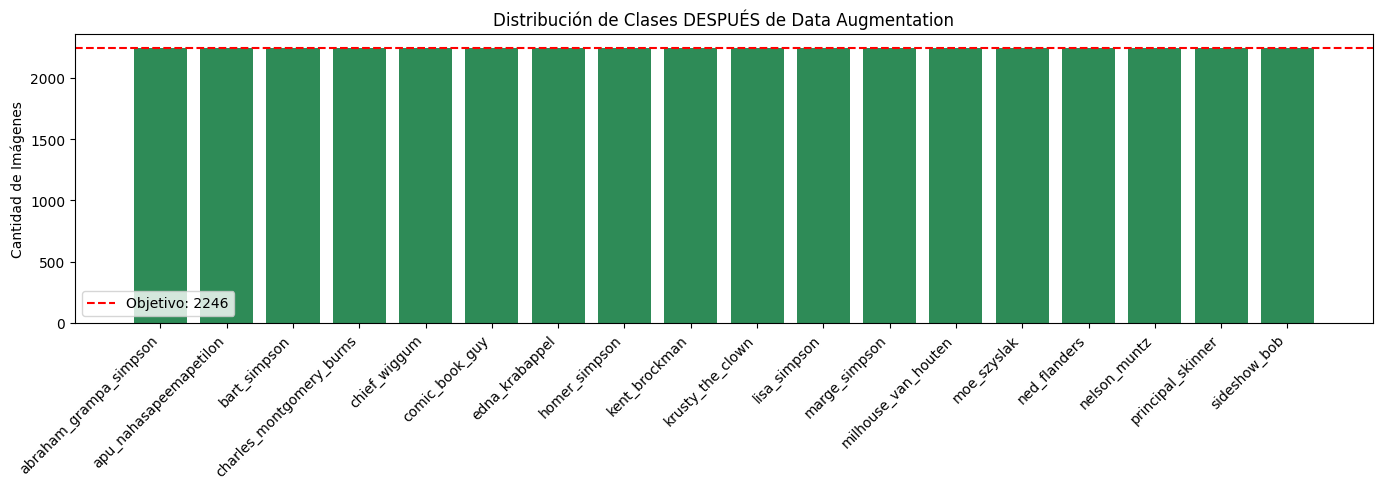

In [ ]:
plt.figure(figsize=(14, 5))
plt.bar(
    [MAP_CHARACTERS[i] for i in unique],
    counts,
    color="seagreen",
)
plt.xticks(rotation=45, ha="right")
plt.title("Distribución de Clases DESPUÉS de Data Augmentation")
plt.ylabel("Cantidad de Imágenes")
plt.axhline(target_count, color="red", linestyle="--",
            label=f"Objetivo: {target_count}")
plt.legend()
plt.tight_layout()
plt.show()

El gráfico de distribución posterior al Data Augmentation confirma la correcta aplicación del proceso, mostrando que todas las clases alcanzan el mismo nivel de representación. La línea horizontal indica el valor objetivo definido, coincidiendo con la altura de todas las barras, lo que evidencia la homogeneización del dataset.
Este balance permite reducir el sesgo del modelo durante el entrenamiento, favoreciendo una mejor capacidad de generalización y un desempeño más equitativo entre todas las clases.


# 6.3 Comparacion de Muestras vs Sinteticas

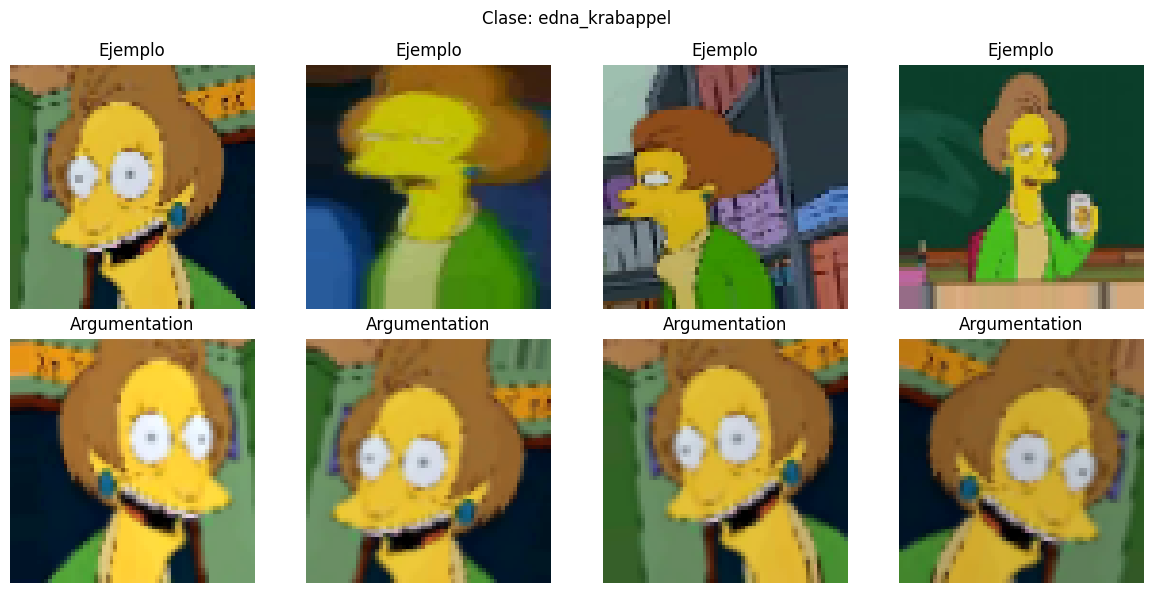

In [ ]:
# Mostrar algunas imágenes sintéticas vs originales de una clase con menos muestras
clase_demo = 6  # una de las clases con menos muestras es edna krabappel
idx_orig = np.where(y == clase_demo)[0][:4]

h = 6 # alto de la grilla
w = 6 # ancho de la grilla

fig, axs = plt.subplots(2, 4, figsize=(12, 6))
for i, idx in enumerate(idx_orig):
    axs[0, i].imshow(cv2.cvtColor(X[idx], cv2.COLOR_BGR2RGB))
    axs[0, i].set_title("Ejemplo")
    axs[0, i].axis("off")

# Generar 4 variaciones augmentadas de la primera imagen
sample = X[idx_orig[0]:idx_orig[0]+1]
flow = augmenter.flow(sample, batch_size=1, seed=SEED)
for i in range(4):
    aug = next(flow)[0].astype(np.uint8)
    axs[1, i].imshow(cv2.cvtColor(aug, cv2.COLOR_BGR2RGB))
    axs[1, i].set_title("Argumentation")
    axs[1, i].axis("off")

plt.suptitle(f"Clase: {MAP_CHARACTERS[clase_demo]}", fontsize=12)
plt.tight_layout()
plt.show()

A grades rasgos en esta sección del código se implementamos una visualización gráfica con el fin de comparar las imágenes originales con versiones sintéticas, es decir, que generamos variaciones alteradas de una misma foto para ver cómo se alimentará la red neuronal. Además se agregó el uso de la técnica Data Augmentation mediante un generador. Esto se usó para poder multiplicar artificialmente nuestras imágenes de entrenamiento y darle al modelo ejemplos visuales nuevos constantemente, lo que ayuda directamente a evitar el sobreajuste, y ademas, balancear el numero de datos en las diferentes clases. Cabe destacar que enfocamos esta demostración específicamente en la clase 6 (Edna Krabappel) puesto que estaremos aplicando este método para apoyar a las categorías que tienen menos muestras y así equilibrar el aprendizaje del modelo.

A nivel mas especifico lo que hace cada parte del codigo es con clase_demo = 6: definir exactamente qué personaje se va a analizar. Ayuda a filtrar el dataset para aislar solo las fotos de Edna Krabappel en este caso.

Luego con figsize=(12, 6) configuramos las dimensiones del lienzo del gráfico, es decir, el ancho y el largo, lo que asegura que las imagenes se rendericen con buen tamaño y no se vean deformes o aplastadas.

Con cv2.COLOR_BGR2RGB corregimos el formato de color. OpenCV lee las imágenes en formato BGR (azul, verde, rojo), es decir, al reves, pero la librería de gráficos las necesita en RGB. Esto evita que los personajes salgan con la piel azul. Basicamente estamos haciendo que los personajes pasen a RGB y no se mantengan en BGR.

Con batch_size=1 le indicamos al generador que tome y devuelva exactamente una sola imagen alterada por cada paso del ciclo.

Con seed=SEED hacemos que los giros o zoom sean siempre los mismos, esto lo hacemos para garantizar que las imágenes sintéticas generadas sean exactamente las mismas cada vez que corras la celda.

Finalmente, con fontsize=12 determinamos el tamaño de la fuente del título general del gráfico para que sea legible en la presentación.

### **6.4. Normalización de los datos**

En esta etapa se realiza la normalización de las imágenes. Originalmente, los píxeles poseen valores enteros entre 0 y 255, donde 0 representa ausencia de color y 255 la máxima intensidad. Al dividir cada píxel por 255, los valores quedan escalados en un rango entre 0 y 1. Esta transformación facilita el aprendizaje de la CNN, mejorando la estabilidad numérica y permitiendo un entrenamiento más eficiente del modelo.

In [ ]:
# Normalizar las imágenes de entrenamiento
X_train = X / 255.0

# Aplicar el mismo escalado al set de prueba
X_test  = X_t / 255.0

**JUSTIFICACIÓN:**

- Este proceso facilita el trabajo de la red, ya que resulta más eficiente procesar valores pequeños y escalados que números grandes. Además, muchas funciones de activación, como ReLU o sigmoide, presentan un mejor comportamiento cuando los datos se encuentran en rangos cercanos a 0.

- La normalización también mejora el entrenamiento del modelo. La red aprende ajustando sus parámetros mediante pequeños cambios llamados gradientes. Si los valores de entrada son demasiado grandes, estos ajustes pueden volverse inestables o bruscos, dificultando el aprendizaje.

- Por ello, al llevar todos los píxeles a un mismo rango de valores, la CNN puede entrenarse de forma más estable y eficiente, enfocándose en aprender patrones, formas y características visuales relevantes de las imágenes, en lugar de lidiar con diferencias de escala entre los datos.

### **6.2. Codificación de etiquetas**

In [ ]:
# Cantidad total de clases del dataset
NUM_CLASSES = len(MAP_CHARACTERS)

# Convierte etiquetas a formato One-Hot Encoding
Y_train = keras.utils.to_categorical(y, NUM_CLASSES)
Y_test  = keras.utils.to_categorical(y_t, NUM_CLASSES)

### **6.3. División entrenamiento-validación**

In [ ]:
X_train, X_val, Y_train, Y_val = train_test_split(
    # Imágenes del dataset
    X_train,

    # Etiquetas codificadas
    Y_train,

    # Reserva el 20% para validación
    test_size=0.20,

    # Fija una semilla
    random_state=42,

    # Mezcla aleatoriamente los datos
    shuffle=True
)

print(f"------------------------------------------")
print(f"Entrenamiento: {X_train.shape[0]} imágenes")
print(f"------------------------------------------")
print(f"Validación: {X_val.shape[0]} imágenes")
print(f"------------------------------------------")

------------------------------------------
Entrenamiento: 32342 imágenes
------------------------------------------
Validación: 8086 imágenes
------------------------------------------


## **7. MODELO 1 - CNN BASE**

### **7.1. Comparativa  de  arquitectura CNN**

In [ ]:
# definimos semilla, para que resultados sean reproducibles y que no varien de una ejecucución a otra
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


# Modelo 1

En este primer modelo se define una red convolucional simple para clasificar imágenes de 64x64 píxeles en formato RGB, por eso la entrada tiene 3 canales.

La capa Conv2D utiliza 32 filtros de tamaño 3x3 para extraer características visuales básicas de la imagen, como bordes, formas y texturas.

Luego, MaxPooling2D reduce el tamaño de la información obtenida, conservando las características más importantes.

Después, Flatten convierte los mapas de características en un vector, para que puedan ser procesados por las capas densas.

Finalmente, una capa Dense aprende patrones a partir de esas características, y la capa de salida usa softmax para clasificar la imagen en una de las clases disponibles.

In [ ]:
# Crea una red neuronal secuencial
model = keras.Sequential([

    # Capa convolucional que extrae características de la imagen
    Conv2D(32, (3,3),
           activation='relu',
           input_shape=(64,64,3)),

    # Reduce dimensiones conservando información importante
    MaxPooling2D((2,2)),

    # Convierte los mapas de activación en un vector
    Flatten(),

    # Capa densa para aprender patrones complejos
    Dense(128, activation='relu'),

    # Capa de salida para clasificación multiclase
    Dense(NUM_CLASSES, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### **7.2. Compilación del modelo**
En esta parte se compila el modelo utilizando como optimizador adam, esto ya que es el que mejor se adaptaba a la estructura

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### **7.3. Entrenamiento del modelo**

en este apartado es donde el modelo se entrena, se define como base epochs 20, y batch_size 64 como fijos, para que el impacto se note en la estructura y composicion de la cnn y no en los hiperparametros

In [ ]:
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    shuffle=True,
    epochs=20,
    batch_size=64
)

Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.4774 - loss: 1.8185 - val_accuracy: 0.5923 - val_loss: 1.4220
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6656 - loss: 1.1637 - val_accuracy: 0.6406 - val_loss: 1.2264
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7567 - loss: 0.8549 - val_accuracy: 0.6527 - val_loss: 1.2034
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8218 - loss: 0.6364 - val_accuracy: 0.6531 - val_loss: 1.2410
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8667 - loss: 0.4788 - val_accuracy: 0.6516 - val_loss: 1.3044
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8951 - loss: 0.3712 - val_accuracy: 0.6470 - val_loss: 1.4170
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9189 - loss: 0.2866 - val_accuracy: 0.6352 - val_loss: 1.5604
Epoch 8/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9346 - loss: 0.2262 - val_accuracy:

# Metricas del entrenamiento
a continuacion se muestran los resultados del entrenamiento utilizando metricas proveidas por la funcinón classification_report, la cual nos da valores como f1-socore etc

In [ ]:
loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print(f"Accuracy: {acc*100:.2f}%  |  Loss: {loss:.4f}")

# Predicciones
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(Y_test, axis=1)

# Reporte por clase
print(classification_report(y_true, y_pred, target_names=list(MAP_CHARACTERS.values())))


Accuracy: 90.34%  |  Loss: 0.6591
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.83      0.83      0.83        48
  apu_nahasapeemapetilon       0.96      1.00      0.98        50
            bart_simpson       0.88      0.88      0.88        50
charles_montgomery_burns       0.87      0.96      0.91        48
            chief_wiggum       0.98      0.90      0.94        50
          comic_book_guy       0.78      0.96      0.86        49
          edna_krabappel       0.92      0.90      0.91        50
           homer_simpson       0.90      0.70      0.79        50
           kent_brockman       0.81      0.96      0.88        50
        krusty_the_clown       1.00      0.90      0.95        50
            lisa_simpson       0.89      0.80      0.84        50
           marge_simpson       0.98      0.92      0.95        50
     milhouse_van_houten       0.98      0.90      0.94        49
 

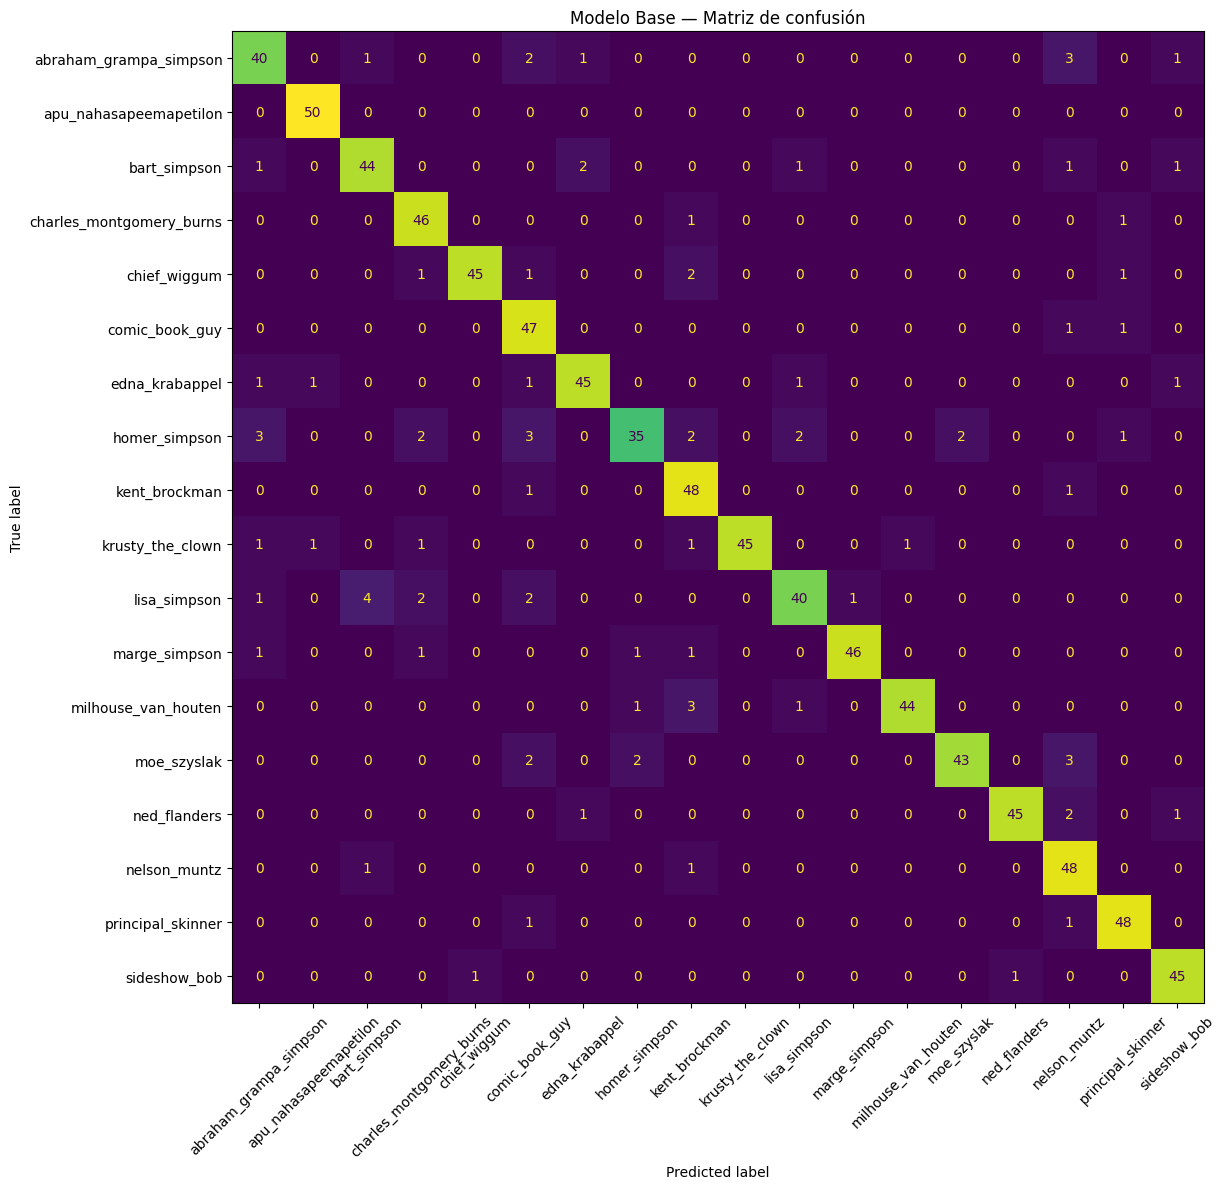

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(cm, display_labels=list(MAP_CHARACTERS.values()))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Modelo Base — Matriz de confusión')
plt.tight_layout()
plt.show()

# Modelo 2 — CNN con mayor profundidad

Este segundo modelo es una versión más profunda que el modelo base.
A diferencia del primer modelo, se agregan más bloques convolucionales para que la red pueda aprender características más complejas de las imágenes.

El primer bloque utiliza 64 filtros, orientados a detectar características simples como bordes, colores y texturas.
Luego, los siguientes bloques utilizan 128 filtros, permitiendo capturar patrones más detallados e intermedios.

Después de cada capa convolucional se aplica  MaxPooling2D para reducir el tamaño de los mapas de características y conservar la información más importante.

Finalmente, se usa Flatten para transformar la información en un vector, una capa densa de 32 neuronas,para reducir el sobreajuste y una capa de salida con softmax para clasificar la imagen en una de las clases disponibles.

In [ ]:
modelo_2 = keras.Sequential([

    # Bloque 1 — igual que Modelo 1
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D((2,2)),

    # Bloque 2 — única diferencia: más profundidad
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

modelo_2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

modelo_2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 815,410 (3.11 MB)

 Trainable params: 815,410 (3.11 MB)

 Non-trainable params: 0 (0.00 B)

# Entrenamiento
en esta parte se entrena el modelo ,tomando los parametros fijos(epochs = 20, batch_size=64)

In [ ]:
history_model_2 = modelo_2.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, Y_val),
    shuffle=True,
    verbose=1
)

Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.5000 - loss: 1.7035 - val_accuracy: 0.6243 - val_loss: 1.3012
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6971 - loss: 1.0413 - val_accuracy: 0.6996 - val_loss: 1.0296
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7840 - loss: 0.7476 - val_accuracy: 0.7361 - val_loss: 0.9071
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8425 - loss: 0.5440 - val_accuracy: 0.7502 - val_loss: 0.8602
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8865 - loss: 0.3923 - val_accuracy: 0.7454 - val_loss: 0.9292
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9148 - loss: 0.2921 - val_accuracy: 0.7627 - val_loss: 0.9358
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9348 - loss: 0.2207 - val_accuracy: 0.7570 - val_loss: 1.0333
Epoch 8/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9461 - loss: 0.1741 - val_accuracy

Accuracy: 95.06%  |  Loss: 0.3390
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.93      0.88      0.90        48
  apu_nahasapeemapetilon       0.96      1.00      0.98        50
            bart_simpson       0.93      0.86      0.90        50
charles_montgomery_burns       0.92      0.96      0.94        48
            chief_wiggum       0.98      0.98      0.98        50
          comic_book_guy       1.00      1.00      1.00        49
          edna_krabappel       0.92      0.96      0.94        50
           homer_simpson       0.93      0.80      0.86        50
           kent_brockman       0.98      0.96      0.97        50
        krusty_the_clown       0.98      0.94      0.96        50
            lisa_simpson       0.88      0.98      0.92        50
           marge_simpson       1.00      0.96      0.98        50
     milhouse_van_houten       0.96      1.00      0.98        49
 

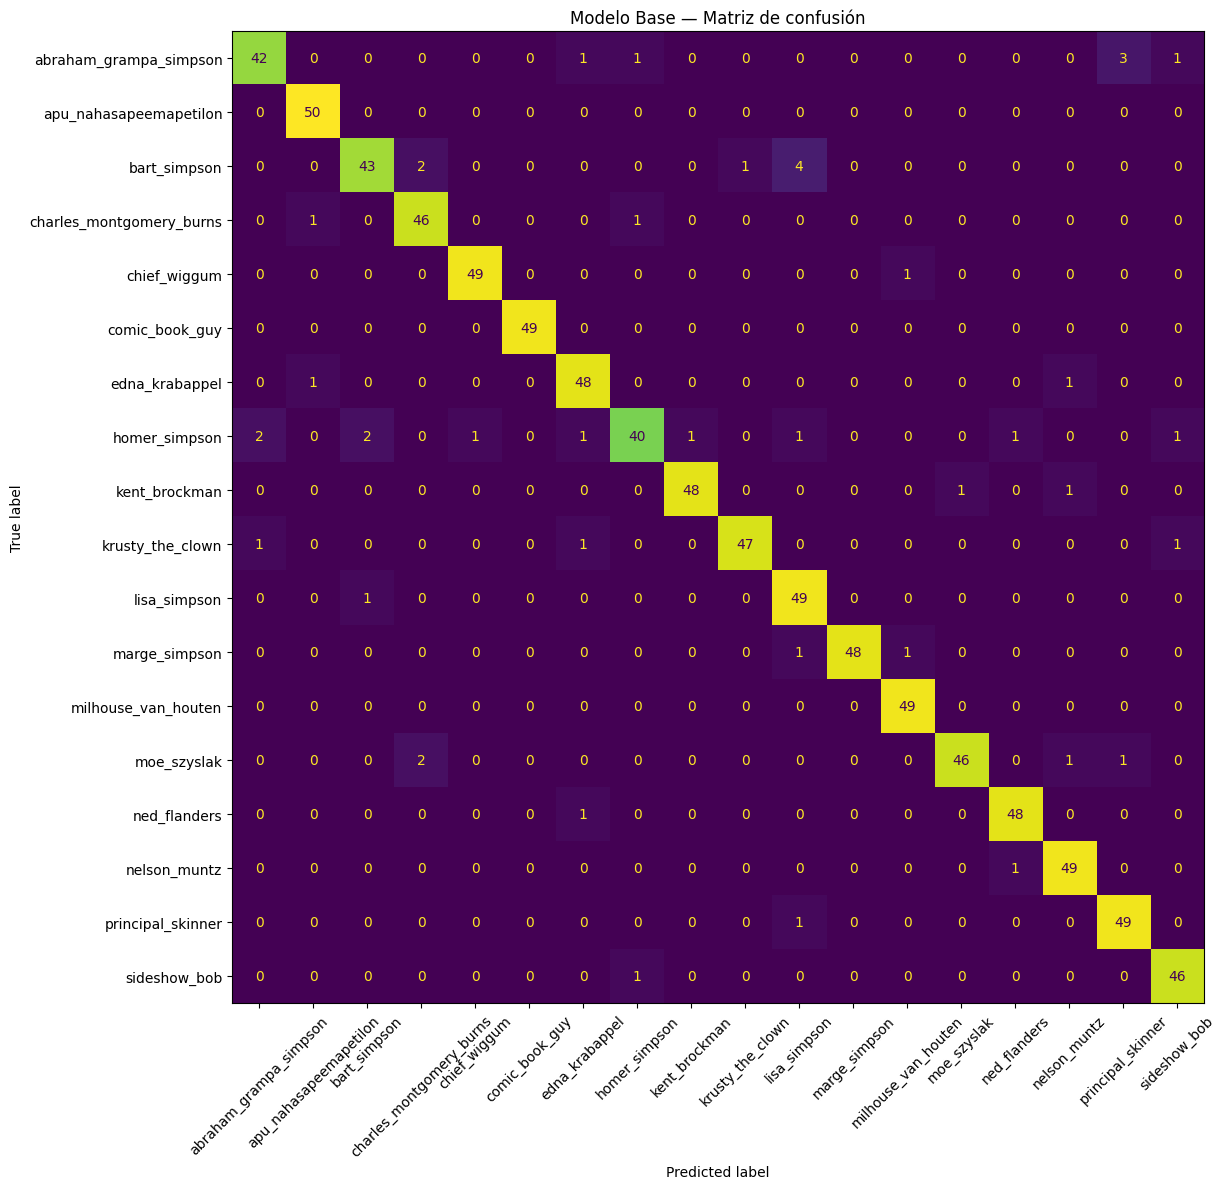

In [ ]:

loss, acc = modelo_2.evaluate(X_test, Y_test, verbose=0)
print(f"Accuracy: {acc*100:.2f}%  |  Loss: {loss:.4f}")

# Predicciones
y_pred = np.argmax(modelo_2.predict(X_test), axis=1)
y_true = np.argmax(Y_test, axis=1)

# Reporte por clase
print(classification_report(y_true, y_pred, target_names=list(MAP_CHARACTERS.values())))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(cm, display_labels=list(MAP_CHARACTERS.values()))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Modelo Base — Matriz de confusión')
plt.tight_layout()
plt.show()

# Comparativa de acurracy y loss, entre ambas cnn

en este apartado se grafican el loss y accuracy de ambos modelos, y en base a el que tenga mejor comportamioento sera el elegido como modelo base

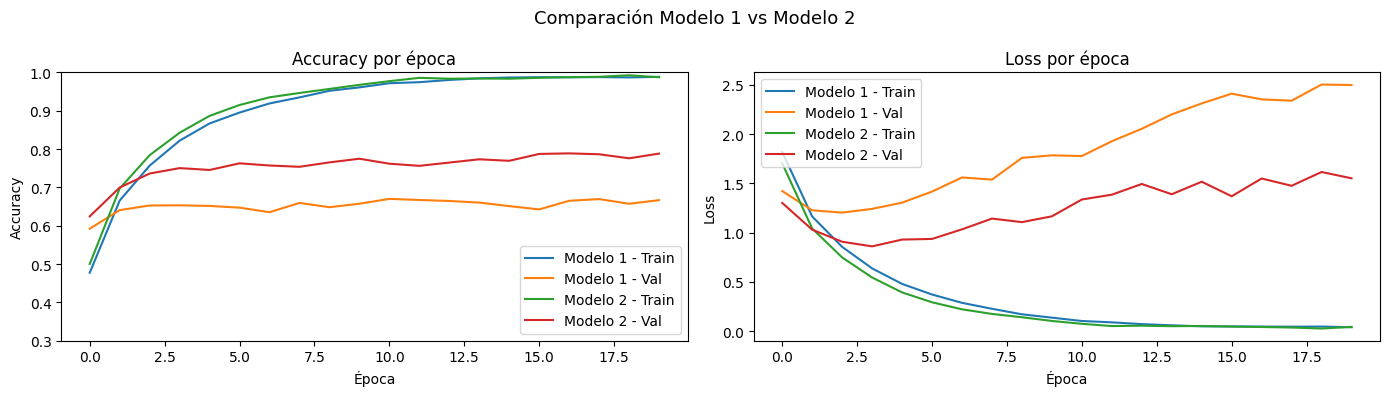

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Modelo 1 - Train')
axes[0].plot(history.history['val_accuracy'], label='Modelo 1 - Val')

axes[0].plot(history_model_2.history['accuracy'], label='Modelo 2 - Train')
axes[0].plot(history_model_2.history['val_accuracy'], label='Modelo 2 - Val')

axes[0].set_title('Accuracy por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0.3, 1.0])
axes[0].legend()


# Loss
axes[1].plot(history.history['loss'], label='Modelo 1 - Train')
axes[1].plot(history.history['val_loss'], label='Modelo 1 - Val')

axes[1].plot(history_model_2.history['loss'], label='Modelo 2 - Train')
axes[1].plot(history_model_2.history['val_loss'], label='Modelo 2 - Val')

axes[1].set_title('Loss por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Comparación Modelo 1 vs Modelo 2', fontsize=13)
plt.tight_layout()
plt.show()

## Modelo Ganador

Tras comparar ambas arquitecturas bajo las mismas condiciones de entrenamiento (epochs=20, batch_size=64, optimizador Adam por defecto, mismo conjunto de validación), el Modelo 2 es seleccionado como modelo ganador.

| Métrica         | Modelo 1 | Modelo 2 |
|-----------------|----------|----------|
| Accuracy (test) | 89.89%   | 94.83%   |
| Loss (test)     | 0.4798   | 0.3742   |
| F1-score macro  | 0.90     | 0.95     |
| Val accuracy (época 20) | ~0.61 | ~0.78 |

La diferencia no se explica por los hiperparámetros de entrenamiento, ya que ambos modelos los comparten exactamente. La ventaja del Modelo 2 proviene de su mayor profundidad convolucional: el segundo bloque Conv2D → MaxPooling2D le permite aprender representaciones jerárquicas más ricas, combinando características simples como bordes, colores y texturas en patrones más complejos como contornos faciales, accesorios y proporciones, que el Modelo 1 no logra capturar con un solo bloque.

Aunque la diferencia en accuracy global no es dramática (89.89% vs 94.83%), la verdadera ventaja del Modelo 2 se evidencia al analizar el rendimiento por clase. En el Modelo 1 varias clases quedan por debajo de F1=0.90, mientras que en el Modelo 2 el F1-score mínimo entre las 18 clases es 0.87 y la mayoría se sitúa entre 0.94 y 1.00. Esto demuestra que el modelo no solo clasifica mejor en promedio, sino que lo hace de forma más consistente y equilibrada entre todos los personajes.

Esto se confirma también en las curvas de entrenamiento: mientras el Modelo 1 muestra sobreajuste desde la época 6 con val_loss creciendo de forma sostenida, el Modelo 2 mantiene una val_accuracy más alta y estable durante todo el entrenamiento, evidenciando una mejor capacidad de generalización.

## Arquitectura propuesta

El Modelo 2 se establece como arquitectura base para iteraciones futuras de mejora. Su estructura demostró ser lo suficientemente expresiva para superar el objetivo del 85% de accuracy planteado al inicio del trabajo, alcanzando un rendimiento consistente en las 18 clases del dataset.

    Entrada (64×64×3)
         ↓
    Conv2D(32, 3×3, ReLU) → MaxPooling2D(2×2)
         ↓
    Conv2D(32, 3×3, ReLU) → MaxPooling2D(2×2)
         ↓
    Flatten → Dense(128, ReLU) → Dense(18, Softmax)

Sin embargo, el sobreajuste identificado en ambos modelos (accuracy de entrenamiento 0.98 vs validación 0.78) representa el principal desafío a resolver. La red aprende representaciones muy ajustadas al set de entrenamiento que no siempre transfiere con la misma eficiencia a datos nuevos. A partir de esta arquitectura base, los experimentos de mejora propuestos son:

- Dropout: agregar capas Dropout(0.3 a 0.5) después de la capa densa de 128 neuronas para penalizar la co-adaptación de neuronas y forzar representaciones más robustas.
- Reducción de neuronas densas: probar Dense(64) en lugar de Dense(128) para reducir la capacidad de memorización del clasificador.
- BatchNormalization: incorporar normalización después de cada bloque convolucional para estabilizar los gradientes y reducir el sobreajuste sin sacrificar profundidad.
- EarlyStopping: detener el entrenamiento automáticamente cuando la val_loss deje de mejorar, evitando las épocas donde la brecha entre train y validación se amplía innecesariamente.

## **9. MEJORA  DE MODELO BASE (EN PROCESO)**

En el punto 2 vimos que el modelo 2, analizaba y capturaba mejor los patrones de las imaganes, si lo comparamos con el primero, pero aún asi queda sobre ajustado, para solucionar estre problema se tomara el segundo modelo y se modificara un hiperparametro a la ves.

los hierparametros seleccionados son
- Dropout: agregar capas Dropout(0.3 a 0.5) después de la capa densa de 128 neuronas para penalizar la co-adaptación de neuronas y forzar representaciones más robustas.
- Reducción de neuronas densas: probar Dense(64) en lugar de Dense(128) para reducir la capacidad de memorización del clasificador.
- BatchNormalization: incorporar normalización después de cada bloque convolucional para estabilizar los gradientes y reducir el sobreajuste sin sacrificar profundidad.
- EarlyStopping: detener el entrenamiento automáticamente cuando la val_loss deje de mejorar, evitando las épocas donde la brecha entre train y validación se amplía innecesariamente.

- Learning_rate: probar con disitintos tipos de desde altos(0,1) a muy bajos(0.0001)

# Mejora 1, Dropout
empezaremos probando primero una capa de drop out - para ello y por cosas de capacidad del colab solo sec probara desde 0,2 a 0.5, esto dado que al ser muchas trabajo aveces se cae.

para ello y no reperir la misma estructura en cada uno se crea una funcion, la cual por parametro, recibira el dropout definido en un diccionario y dentro tendra la estructura del modelo ganador, en este caso, el modelo 2, y luego en el dropout sera agregado luego de las neuronas

In [ ]:
# definicion de rangos a explorar

rangos= {
    'Dropout 0.2':0.2,
    'Dropout 0.3':0.3,
    'Dropout 0.4':0.4,
    'Dropout 0.5':0.5
}

In [ ]:
def generate_model(drop_out):

  modelo = keras.Sequential([


    # Bloque 1 — igual que Modelo 1
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D((2,2)),

    # Bloque 2 — única diferencia: más profundidad
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(drop_out),
    Dense(NUM_CLASSES, activation='softmax')
  ])

  modelo.compile(
      optimizer='adam',
      loss='categorical_crossentropy',
      metrics=['accuracy']
  )

  modelo.summary()

  return modelo


# entrenamiento de cada modelo

para entrenar cada uno de los modelos, y que cada uno sea entrenado desde 0, se recorrera con un ciclo for el diccionario declarado arriba con cada uno de los valores, y por se llamara a la funcion definida para la generacion del modelo y entrenamiento

In [ ]:
resultados = {}

for exp in rangos:
    print(f"\n{'='*50}")
    print(f"Experimento: {exp}")
    print(f"{'='*50}")

    SEED = 42
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = generate_model(rangos[exp])

    history = model.fit(
        X_train, Y_train,
        epochs=20,
        batch_size=64,
        validation_data=(X_val, Y_val),
        shuffle=True,
        verbose=1
    )

    loss, acc = model.evaluate(X_test, Y_test, verbose=0)
    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(Y_test, axis=1)
    report = classification_report(
        y_true, y_pred,
        target_names=list(MAP_CHARACTERS.values()),
        output_dict=True
    )

    print(f"Accuracy: {acc*100:.2f}%  |  Loss: {loss:.4f}")
    print(classification_report(
        y_true, y_pred,
        target_names=list(MAP_CHARACTERS.values())
    ))

    resultados[exp] = {
        'history'         : history,
        'accuracy'        : acc,
        'loss'            : loss,
        'f1_macro'        : report['macro avg']['f1-score'],
        'precision_macro' : report['macro avg']['precision'],
        'recall_macro'    : report['macro avg']['recall']
    }


Experimento: Dropout 0.2


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 815,410 (3.11 MB)

 Trainable params: 815,410 (3.11 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 815,410 (3.11 MB)

 Trainable params: 815,410 (3.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.3861 - loss: 2.0537 - val_accuracy: 0.5913 - val_loss: 1.4340
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5766 - loss: 1.4325 - val_accuracy: 0.6735 - val_loss: 1.1300
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6502 - loss: 1.1735 - val_accuracy: 0.6975 - val_loss: 1.0120
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6916 - loss: 1.0094 - val_accuracy: 0.7357 - val_loss: 0.9013
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7272 - loss: 0.8859 - val_accuracy: 0.7575 - val_loss: 0.8185
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7546 - loss: 0.7898 - val_accuracy: 0.7677 - val_loss: 0.7725
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7796 - loss: 0.7047 - val_accuracy: 0.7776 - val_loss: 0.7445
Epoch 8/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7963 - loss: 0.6447 - val_accuracy: 

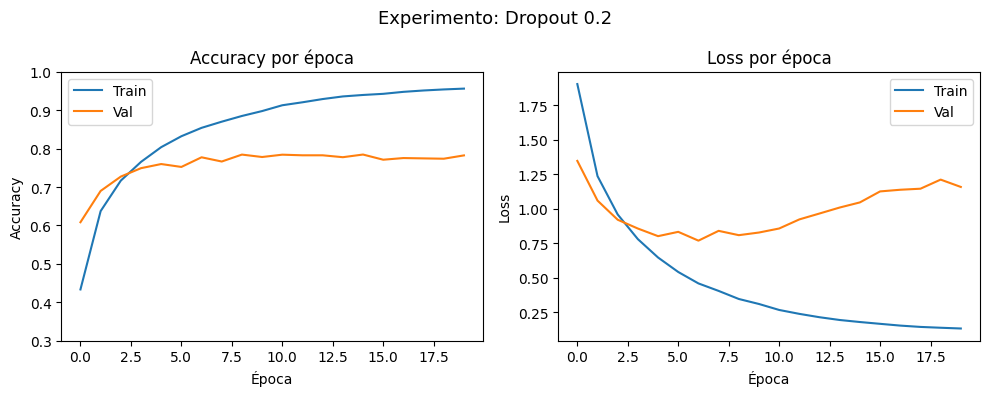

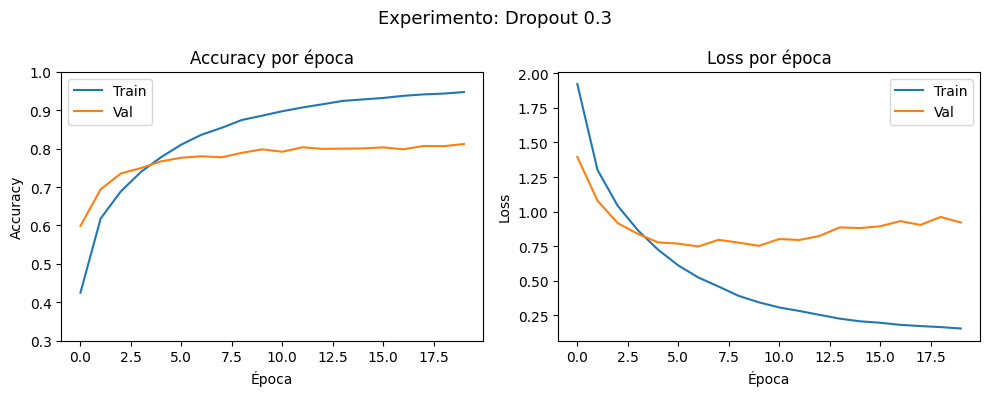

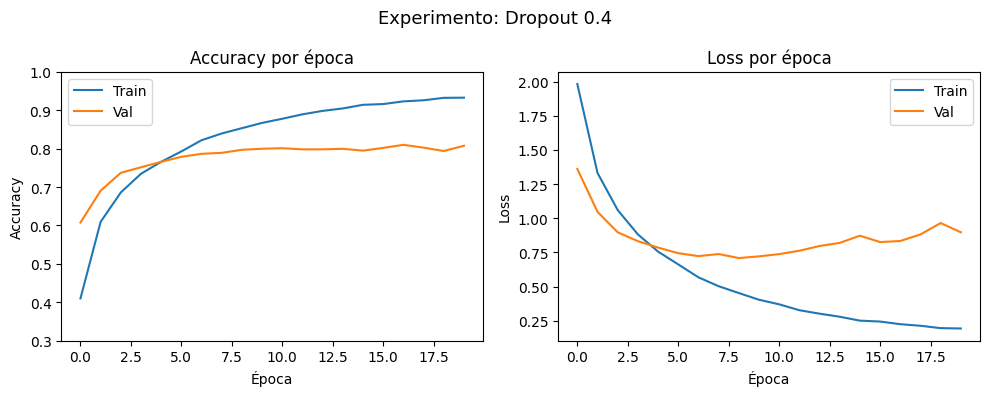

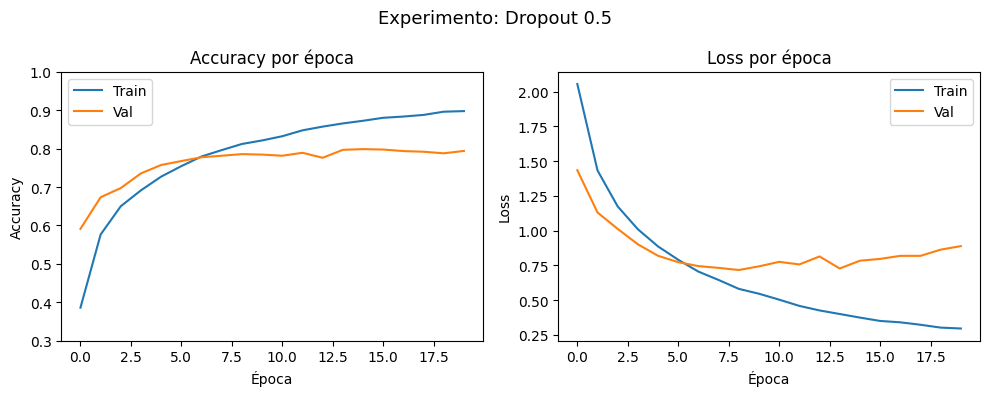

In [ ]:
for exp in resultados:
    h = resultados[exp]['history']

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Accuracy
    axes[0].plot(h.history['accuracy'],     label='Train')
    axes[0].plot(h.history['val_accuracy'], label='Val')
    axes[0].set_title('Accuracy por época')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim([0.3, 1.0])
    axes[0].legend()

    # Loss
    axes[1].plot(h.history['loss'],     label='Train')
    axes[1].plot(h.history['val_loss'], label='Val')
    axes[1].set_title('Loss por época')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.suptitle(f'Experimento: {exp}', fontsize=13)
    plt.tight_layout()
    plt.show()

## Análisis de experimentos con Dropout

Los experimentos evaluaron el impacto de distintos valores de Dropout sobre la arquitectura base (Modelo 2), manteniendo fijos todos los demás hiperparámetros.

- Dropout 0.2 (94.38%): el valor más bajo de regularización. Mejora levemente la loss respecto al modelo base (0.30 vs 0.37), pero la val_accuracy se estanca alrededor de 0.78, similar al modelo sin Dropout. La regularización es insuficiente para reducir el sobreajuste de forma significativa.

- Dropout 0.3 (96.63%): mejor resultado de todos los experimentos. La val_accuracy alcanza 0.81 en las últimas épocas y la loss de test cae a 0.1702, la más baja registrada. El F1-score mínimo entre las 18 clases es 0.92, con ned_flanders y nelson_muntz alcanzando F1=1.00. Este valor de Dropout logra el mejor equilibrio entre regularización y capacidad de aprendizaje.

- Dropout 0.4 (95.62%): buen resultado, segundo mejor del experimento. La val_accuracy sube hasta ~0.81 de forma estable, pero la accuracy de test es inferior a Dropout 0.3 en casi 1 punto porcentual, lo que indica que el nivel de regularización comienza a limitar levemente la capacidad del modelo.

- Dropout 0.5 (93.60%): el valor más alto evaluado muestra el peor resultado del grupo. La train accuracy en época 20 cae a 0.89, significativamente menor que en los otros experimentos, lo que indica que desactivar el 50% de las neuronas en cada paso dificulta el aprendizaje y reduce tanto la accuracy de entrenamiento como la de test.

En conclusión, Dropout 0.3 es seleccionado como el ganador en este experimento

## **10. EVALUACIÓN DEL MEJOR MODELO**

## **11. JUSTIFICACIÓN DEL MODELO FINAL**

## **12. CONCLUSIÓN**